# Survival Analysis: Time to Purchase After Add to Cart

This notebook models how long it takes users to purchase after adding an item to their cart, and whether that time differs by acquisition channel, device type, or user type (new vs returning).

Funnel analysis (notebooks 01 to 03) answered *whether* users convert. This notebook answers *how fast*, and treats users who never purchased as censored observations rather than dropping them.

The analysis uses `funnel_sequential` rather than `funnel_first_touch`, since earlier notebooks identified instrumentation drift in early November that makes `funnel_first_touch` timestamps unreliable for time based analysis.

## 1. Setup

In [27]:
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

## 2. Load data

Two tables are needed:

- `funnel_survival`: one row per user, with first touch channel, device category, and user type
- `funnel_sequential`, filtered to users who reached `add_to_cart`: the timestamps needed to build duration and event columns

In [28]:
from google.cloud import bigquery

client = bigquery.Client(project="funnel-analysis-project-503810")

covariates_query = """
    SELECT *
    FROM `funnel-analysis-project-503810.funnel_analysis.funnel_survival`
"""

df_covariates = client.query(covariates_query).to_dataframe()

print(df_covariates.shape)
df_covariates.head()

(79421, 4)


,user_pseudo_id,channel,device_category,user_type
0,65287046.9188528481,(data deleted),desktop,returning
1,78729044.0766356919,(data deleted),desktop,returning
2,8760245.3046399244,(data deleted),desktop,returning
3,8454698.6535932382,(data deleted),desktop,returning
4,8083159.2419151953,(data deleted),desktop,returning


In [29]:
sequential_query = """
    SELECT *
    FROM `funnel-analysis-project-503810.funnel_analysis.funnel_sequential`
    WHERE t_add_to_cart_seq IS NOT NULL
"""

df_survival = client.query(sequential_query).to_dataframe()
print(df_survival.shape)
df_survival.head()

(1850, 6)


,user_pseudo_id,t_page_view,t_view_item_seq,t_add_to_cart_seq,t_begin_checkout_seq,t_purchase_seq
0,18938448.3710776022,2020-11-06 19:42:47.520534+00:00,2020-11-06 19:43:23.321828+00:00,2020-11-16 23:18:48.396653+00:00,NaT,NaT
1,1942024.1685438905,2020-11-18 03:22:57.088154+00:00,2020-11-18 03:23:02.086427+00:00,2020-11-18 03:23:17.745499+00:00,NaT,NaT
2,5151875.2074190145,2020-11-18 02:17:48.949815+00:00,2020-11-18 02:18:00.860939+00:00,2020-11-18 02:18:05.725278+00:00,NaT,NaT
3,86490981.6068274559,2020-11-28 00:59:59.141604+00:00,2020-11-28 01:01:48.888598+00:00,2020-11-28 01:02:55.680503+00:00,NaT,NaT
4,2860758.2794962378,2020-11-18 13:12:19.264256+00:00,2020-11-18 13:19:59.876358+00:00,2020-11-18 13:35:20.971054+00:00,NaT,NaT


## 3. Build the modeling table

The two tables are joined on `user_pseudo_id`. A left join keeps all users who reached `add_to_cart`, even in the unlikely case a covariate is missing.

In [30]:
df = df_survival.merge(df_covariates, on='user_pseudo_id', how='left')
print(df.shape)

(1850, 9)


### Event flag

`event = 1` if the user has a `t_purchase_seq` timestamp, meaning they purchased. `event = 0` means the user is censored: they added to cart but did not purchase within the observed window.

In [31]:
df['event'] = df['t_purchase_seq'].notna().astype(int)
df['event'].value_counts()

event
0    1506
1     344
Name: count, dtype: int64

### Duration

Duration is measured in hours from `t_add_to_cart_seq` to an end point:

- for purchasers, the end point is `t_purchase_seq`
- for censored users, the end point is a fixed cutoff of December 1, 2020, one moment after the dataset's November window closes

Using "today" as the cutoff would be wrong here, since the dataset is from 2020 and the elapsed time would be meaningless.

In [32]:
cutoff = pd.Timestamp('2020-12-01', tz='UTC')

df['end_time'] = df['t_purchase_seq'].fillna(cutoff)
df['duration'] = (df['end_time'] - df['t_add_to_cart_seq']).dt.total_seconds() / 3600

df['duration'].describe()

count    1850.000000
mean      103.791298
std       115.218573
min         0.026314
25%        11.272734
50%        66.185291
75%       118.735695
max       716.891852
Name: duration, dtype: float64

## 4. Encode covariates

`channel`, `device_category`, and `user_type` are text columns and need to be one hot encoded before any model can use them. `drop_first=True` drops one category per column as the reference level.

In [33]:
df_model = df[['user_type', 'event', 'duration', 'device_category', 'channel']].copy()
df_model = pd.get_dummies(df_model, columns=['channel', 'device_category', 'user_type'], drop_first=True)

df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850 entries, 0 to 1849
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   1850 non-null   int64  
 1   duration                1850 non-null   float64
 2   channel_(none)          1850 non-null   bool   
 3   channel_<Other>         1850 non-null   bool   
 4   channel_cpc             1850 non-null   bool   
 5   channel_organic         1850 non-null   bool   
 6   channel_referral        1850 non-null   bool   
 7   device_category_mobile  1850 non-null   bool   
 8   device_category_tablet  1850 non-null   bool   
 9   user_type_returning     1850 non-null   bool   
dtypes: bool(8), float64(1), int64(1)
memory usage: 43.5 KB


## 5. Cox proportional hazards model

Cox is fit first as a baseline, and its core assumption (proportional hazards) is checked directly against the data rather than assumed.

In [34]:
cox = CoxPHFitter()
cox.fit(df_model, duration_col='duration', event_col='event')
cox.check_assumptions(df_model, p_value_threshold=0.05)

Proportional hazard assumption looks okay.


[]

In [35]:
cox.print_summary()

<lifelines.CoxPHFitter: fitted with 1850 total observations, 1506 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1850
number of events observed = 344
   partial log-likelihood = -2515.81
         time fit was run = 2026-08-03 17:05:52 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
channel_(none)          0.39      1.48      0.31           -0.21            1.00                0.81                2.71
channel_<Other>         0.29      1.34      0.32           -0.34            0.93                0.71                2.52
channel_cpc             0.56      1.75      0.37           -0.17            1.29                0.84                3.62
channel_organic         0.36      1.44      0.31           -0.24            0.97                0.79                2.62
channel_referral        0.19      1.21      0.31           -0.42            0.80                0.66                2.22
device_category_mobile  0.08      1.08      0.11           -0.14            0.30                0.87                1.35
device_category_tablet  0.10      1.11      0.39           -0.66            0.86                0.52                2.36
user_type_returning     0.84      2.32      0.14            0.56            1.12                1.75                3.07

                        cmp to    z      p  -log2(p)
covariate                                           
channel_(none)            0.00 1.28   0.20      2.31
channel_<Other>           0.00 0.90   0.37      1.45
channel_cpc               0.00 1.50   0.13      2.91
channel_organic           0.00 1.18   0.24      2.07
channel_referral          0.00 0.62   0.54      0.89
device_category_mobile    0.00 0.72   0.47      1.09
device_category_tablet    0.00 0.26   0.79      0.33
user_type_returning       0.00 5.85 <0.005     27.61
---
Concordance = 0.57
Partial AIC = 5047.61
log-likelihood ratio test = 33.18 on 8 df
-log2(p) of ll-ratio test = 14.09

### Reading the Cox output

`exp(coef)` is a hazard ratio. Above 1 means a higher chance of purchasing at any given moment relative to the reference category; below 1 means lower.

- `user_type_returning`: hazard ratio 2.32 (95% CI 1.75 to 3.07, p < 0.005). Returning users are about 2.3 times as likely to purchase at any given moment compared to new users, holding channel and device constant.
- All `channel_*` and `device_category_*` rows have p values well above 0.05 and confidence intervals that cross 1, so none of them show a reliable effect on purchase timing in this dataset.
- Concordance is 0.57, only modestly better than random guessing (0.5), which is consistent with the project's broader limitation: GA4 event data alone has limited power to explain conversion behavior.

## 6. Choosing an AFT distribution

Weibull AFT was the original plan for this notebook. Rather than assume Weibull is the right distributional shape, three parametric AFT models are fit and compared by AIC, and the lowest AIC is used going forward.

In [36]:
for name, fitter in [
    ('Weibull', WeibullAFTFitter()),
    ('LogNormal', LogNormalAFTFitter()),
    ('LogLogistic', LogLogisticAFTFitter()),
]:
    fitter.fit(df_model, duration_col='duration', event_col='event')
    print(f"{name} AIC: {fitter.AIC_:.2f}")

Weibull AIC: 3029.14
LogNormal AIC: 2962.17
LogLogistic AIC: 3012.96


LogNormal has the lowest AIC of the three, so it is used as the final AFT model rather than the originally planned Weibull.

In [37]:
aft_full = LogNormalAFTFitter()
aft_full.fit(df_model, duration_col='duration', event_col='event')
aft_full.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 1850 total observations, 1506 right-censored observations>
             duration col = 'duration'
                event col = 'event'
   number of observations = 1850
number of events observed = 344
           log-likelihood = -1471.09
         time fit was run = 2026-08-03 17:05:56 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                               
mu_    channel_(none)         -1.83      0.16      1.63           -5.03            1.37                0.01                3.92
       channel_<Other>        -1.40      0.25      1.69           -4.72            1.91                0.01                6.78
       channel_cpc            -2.57      0.08      1.94           -6.37            1.23                0.00                3.41
       channel_organic        -1.63      0.20      1.62           -4.81            1.55                0.01                4.72
       channel_referral       -0.77      0.46      1.63           -3.96            2.42                0.02               11.24
       device_category_mobile -0.43      0.65      0.54           -1.49            0.64                0.22                1.89
       device_category_tablet  0.01      1.01      2.01           -3.92            3.94                0.02               51.31
       user_type_returning    -4.13      0.02      0.80           -5.70           -2.56                0.00                0.08
       Intercept              13.67  8.68e+05      1.69           10.36           16.99            31678.31            2.38e+07
sigma_ Intercept               2.09      8.12      0.05            2.00            2.19                7.42                8.90

                               cmp to     z      p  -log2(p)
param  covariate                                            
mu_    channel_(none)            0.00 -1.12   0.26      1.94
       channel_<Other>           0.00 -0.83   0.41      1.30
       channel_cpc               0.00 -1.33   0.18      2.44
       channel_organic           0.00 -1.00   0.32      1.66
       channel_referral          0.00 -0.47   0.64      0.65
       device_category_mobile    0.00 -0.79   0.43      1.22
       device_category_tablet    0.00  0.00   1.00      0.00
       user_type_returning       0.00 -5.15 <0.005     21.84
       Intercept                 0.00  8.09 <0.005     50.63
sigma_ Intercept                 0.00 45.09 <0.005       inf
---
Concordance = 0.57
AIC = 2962.17
log-likelihood ratio test = 30.47 on 8 df
-log2(p) of ll-ratio test = 12.49

### Reading the AFT output

In an AFT model, `exp(coef)` is a time ratio rather than a hazard ratio. Below 1 means the covariate shortens time to purchase; above 1 means it lengthens it. This is the opposite direction from a Cox hazard ratio, even though both use the same column name.

`user_type_returning` has `exp(coef)` of about 0.02, meaning a returning user's expected time to purchase is roughly 2 percent of a comparable new user's. If a new user typically takes 100 hours to purchase after adding to cart, a returning user with the same channel and device would be expected to take roughly 2 hours. This is consistent with the Cox result: same underlying finding, described on the opposite scale.

Channel and device again show no significant effect, matching the Cox result.

## 7. Simplified model

Since channel and device were not significant in either model, a simplified model using only `user_type` is fit and compared by AIC. A lower AIC here would mean the extra variables were adding noise rather than explanatory power.

In [38]:
df_simple = df_model[['duration', 'event', 'user_type_returning']]

aft_simple = LogNormalAFTFitter()
aft_simple.fit(df_simple, duration_col='duration', event_col='event')
aft_simple.print_summary()

print(f"Full model AIC: {aft_full.AIC_:.2f}")
print(f"Simplified model AIC: {aft_simple.AIC_:.2f}")

<lifelines.LogNormalAFTFitter: fitted with 1850 total observations, 1506 right-censored observations>
             duration col = 'duration'
                event col = 'event'
   number of observations = 1850
number of events observed = 344
           log-likelihood = -1473.04
         time fit was run = 2026-08-03 17:05:58 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                            
mu_    user_type_returning -3.66      0.03      0.72           -5.06           -2.26                0.01                0.10
       Intercept           11.95  1.55e+05      0.52           10.93           12.98            55680.76            4.32e+05
sigma_ Intercept            2.10      8.14      0.05            2.01            2.19                7.43                8.92

                            cmp to     z      p  -log2(p)
param  covariate                                         
mu_    user_type_returning    0.00 -5.12 <0.005     21.64
       Intercept              0.00 22.86 <0.005    381.78
sigma_ Intercept              0.00 45.13 <0.005       inf
---
Concordance = 0.55
AIC = 2952.08
log-likelihood ratio test = 26.56 on 1 df
-log2(p) of ll-ratio test = 21.90

Full model AIC: 2962.17
Simplified model AIC: 2952.08


The simplified model has a lower AIC than the full model, confirming that channel and device add no real explanatory power here. `user_type` alone is a better founded model than the eight covariate version.

## 8. Adding a behavioral feature

The funnel stage timestamps allow one more feature without any new SQL: the time between `page_view` and `add_to_cart`. This is heavily right skewed (most users add to cart within minutes, a small number take days), so it is log transformed before use.

In [39]:
df_survival['time_to_cart_hours'] = (
    df_survival['t_add_to_cart_seq'] - df_survival['t_page_view']
).dt.total_seconds() / 3600

df_survival['time_to_cart_hours'].describe()

count    1850.000000
mean       48.839933
std       125.808798
min         0.002888
25%         0.014440
50%         0.071185
75%         1.546523
max       667.959244
Name: time_to_cart_hours, dtype: float64

In [40]:
df_survival['log_time_to_cart'] = np.log1p(df_survival['time_to_cart_hours'])

df_model = df_model.merge(
    df_survival[['log_time_to_cart']],
    left_index=True,
    right_index=True,
    how='left',
)

df_behavior = df_model[['duration', 'event', 'user_type_returning', 'log_time_to_cart']]

aft_behavior = LogNormalAFTFitter()
aft_behavior.fit(df_behavior, duration_col='duration', event_col='event')
aft_behavior.print_summary()

print(f"Simplified model AIC: {aft_simple.AIC_:.2f}")
print(f"With behavioral feature AIC: {aft_behavior.AIC_:.2f}")

<lifelines.LogNormalAFTFitter: fitted with 1850 total observations, 1506 right-censored observations>
             duration col = 'duration'
                event col = 'event'
   number of observations = 1850
number of events observed = 344
           log-likelihood = -1468.51
         time fit was run = 2026-08-03 17:05:59 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                            
mu_    log_time_to_cart    -0.39      0.68      0.13           -0.64           -0.13                0.53                0.87
       user_type_returning -2.80      0.06      0.76           -4.29           -1.30                0.01                0.27
       Intercept           12.32  2.24e+05      0.55           11.24           13.40            75984.94            6.63e+05
sigma_ Intercept            2.09      8.12      0.05            2.00            2.19                7.42                8.90

                            cmp to     z      p  -log2(p)
param  covariate                                         
mu_    log_time_to_cart       0.00 -3.00 <0.005      8.54
       user_type_returning    0.00 -3.67 <0.005     12.00
       Intercept              0.00 22.30 <0.005    363.59
sigma_ Intercept              0.00 45.09 <0.005       inf
---
Concordance = 0.60
AIC = 2945.02
log-likelihood ratio test = 35.62 on 2 df
-log2(p) of ll-ratio test = 25.69

Simplified model AIC: 2952.08
With behavioral feature AIC: 2945.02


Adding `log_time_to_cart` improves both AIC and concordance over the `user_type` only model. Its coefficient is negative and significant: users who take longer to add an item to cart tend to purchase faster afterward, once they do add to cart. A plausible explanation is that slow browsing reflects more deliberate intent, while a fast add to cart may be closer to casual or exploratory behavior that is less likely to convert quickly.

`user_type_returning` remains significant in this model, though its magnitude shrinks somewhat, since part of what it was capturing is now shared with `log_time_to_cart`.

## 9. Kaplan-Meier curves

The coefficient tables above are summarized visually here with unadjusted Kaplan-Meier survival curves, split by user type. This shows the same finding without requiring the reader to parse a coefficient table.

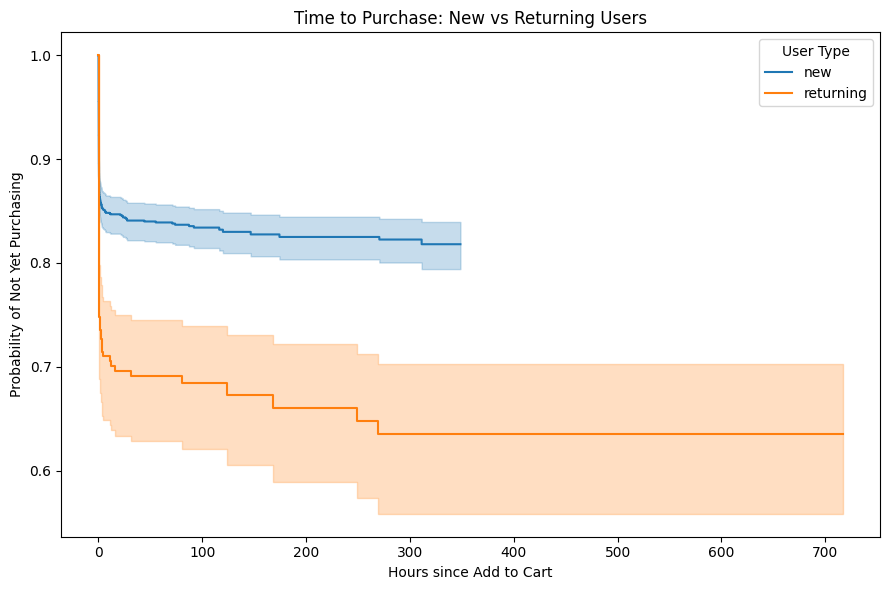

In [41]:
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(9, 6))

for label, group in df.groupby('user_type'):
    kmf.fit(durations=group['duration'], event_observed=group['event'], label=label)
    kmf.plot_survival_function(ax=ax)

plt.title('Time to Purchase: New vs Returning Users')
plt.xlabel('Hours since Add to Cart')
plt.ylabel('Probability of Not Yet Purchasing')
plt.legend(title='User Type')
plt.tight_layout()
plt.savefig('../images/kaplan_meier_user_type.png', dpi=150)
plt.show()

The returning user curve drops sharply in the first few hours and flattens near 0.63, while the new user curve declines slowly and flattens near 0.82. Returning users both purchase more often and purchase faster, matching the model coefficients above. Confidence bands widen substantially past roughly 150 hours, since fewer users survive that long uncensored; the tail of the curve should be read with that in mind.

## 10. Summary

Across three survival models (Cox PH, Weibull AFT, and LogNormal AFT, the best fitting of the three by AIC), one finding is consistent and statistically reliable: **returning users purchase both more often and dramatically faster than new users**, holding channel and device constant.

Acquisition channel and device category showed no statistically significant effect on time to purchase in any model tested. A simplified model using only user type outperformed the full model by AIC, and adding a single behavioral feature, the time between page view and add to cart, improved the model further.

### What this does and does not tell us

The model identifies which segments convert faster and by roughly how much. It does not explain why, since GA4 event data has no visibility into price sensitivity, product interest, or UX friction. The practical use of a model like this is to prioritize where a product or UX team should look next, for example focusing investigation on new user friction rather than acquisition channel. Any specific intervention built on these findings would need to be validated with an A/B test rather than assumed to work from this analysis alone.
